# Day 08. Exercise 04
# Regression

## 0. Imports

In [1]:
!pip install gdown

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings('ignore')

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [3]:
link='https://drive.google.com/uc?id=1L8auBzJEghWFewznhhFpcrqxW4GqcfRY&export=download'
file_name='checker_regression.csv'
gdown.download(link, file_name, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1L8auBzJEghWFewznhhFpcrqxW4GqcfRY&export=download
To: /home/mirshod/Desktop/DSB10_Intro_to_ML.ID_886521-1/src/ex04/checker_regression.csv
100%|██████████| 1.41k/1.41k [00:00<00:00, 6.30MB/s]


'checker_regression.csv'

In [4]:
df=pd.read_csv(f'{file_name}')
df.head()

,uid,num_commits,pageviews,AVG(diff)
0,user_1,62,28.0,NaN
1,user_1,62,28.0,NaN
2,user_1,62,28.0,NaN
3,user_1,62,28.0,NaN
4,user_1,62,28.0,NaN


In [5]:
df.fillna(0, inplace=True)

In [6]:
X = df.drop(['num_commits', 'uid'], axis=1)
y = df['num_commits']

In [7]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=21)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [ ]:
def crossval(n_splits, X, y, model):
  kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
  rmse_list = []
  for train_index, test_index in kf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_list.append(rmse)
    y_train_pred = model.predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    print(f'train - {train_rmse:.1f}   |   test - {rmse:.1f}')
  print('Average RMSE on crossval is', np.mean(rmse_list))

In [9]:
lin_reg=LinearRegression(fit_intercept=True)
crossval(10, X, y, lin_reg)

train - 30.6   |   test - 24.9
train - 30.1   |   test - 29.5
train - 30.9   |   test - 20.4
train - 29.4   |   test - 34.7
train - 29.9   |   test - 30.9
train - 29.2   |   test - 36.0
train - 27.8   |   test - 44.9
train - 30.8   |   test - 20.4
train - 30.3   |   test - 27.2
train - 30.0   |   test - 30.3
Average RMSE on crossval is 29.91737491461176


In [10]:
dec_tree=DecisionTreeRegressor(max_depth=8)
crossval(10, X, y, dec_tree)

train - 4.8   |   test - 14.8
train - 5.2   |   test - 28.3
train - 5.2   |   test - 0.0
train - 4.1   |   test - 18.7
train - 4.8   |   test - 21.3
train - 4.8   |   test - 9.5
train - 4.4   |   test - 43.9
train - 5.2   |   test - 12.9
train - 5.2   |   test - 55.2
train - 5.2   |   test - 13.9
Average RMSE on crossval is 21.854837235031663


In [11]:
ran_for=RandomForestRegressor(max_depth=12)
crossval(10, X, y, ran_for)

train - 9.0   |   test - 12.1
train - 9.1   |   test - 17.4
train - 9.7   |   test - 0.9
train - 8.2   |   test - 19.5
train - 9.4   |   test - 15.7
train - 9.1   |   test - 9.3
train - 7.0   |   test - 35.7
train - 9.2   |   test - 10.7
train - 6.6   |   test - 49.8
train - 10.0   |   test - 5.4
Average RMSE on crossval is 17.650529448160434


## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [12]:
y_pred_lin_reg = lin_reg.predict(X_test)
print("Predictions made for Linear Regression.")

Predictions made for Linear Regression.


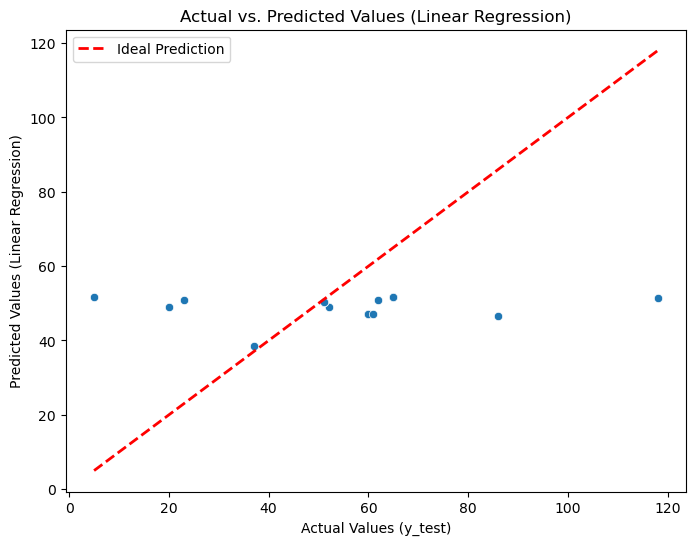

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_lin_reg)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Prediction')
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (Linear Regression)')
plt.title('Actual vs. Predicted Values (Linear Regression)')
plt.legend()
plt.show()

In [14]:
y_pred_dec_tree = dec_tree.predict(X_test)
print("Predictions made for Decision Tree Regressor.")

Predictions made for Decision Tree Regressor.


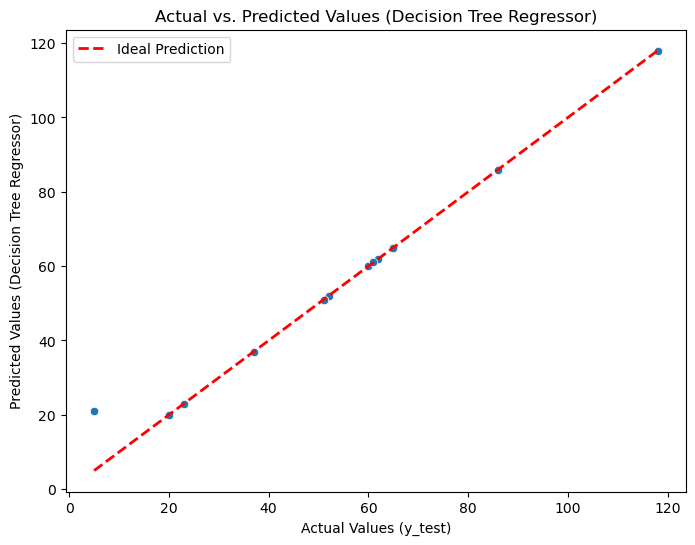

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_dec_tree)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Prediction')
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (Decision Tree Regressor)')
plt.title('Actual vs. Predicted Values (Decision Tree Regressor)')
plt.legend()
plt.show()

In [16]:
y_pred_ran_for = ran_for.predict(X_test)
print("Predictions made for Random Forest Regressor.")

Predictions made for Random Forest Regressor.


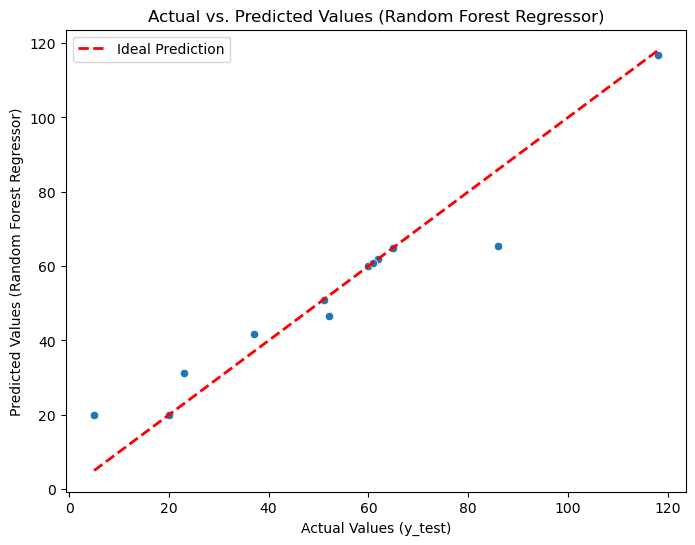

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_ran_for)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Prediction')
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (Random Forest Regressor)')
plt.title('Actual vs. Predicted Values (Random Forest Regressor)')
plt.legend()
plt.show()

### In ideal case, all points of graph lies in (y=x) line!